In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "make",
    "model",
    "vehicle class",
    "transmission",
    "fuel"
]

numerical_features = [
    "year",
    "engine size",
    "cylinders",
    "hwy (l/100 km)",
    "emissions"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (18044, 10)
Testing data: (4511, 10)


In [31]:
target = "comb (l/100 km)"

features = [
    "year",
    "make",
    "model",
    "vehicle class",
    "engine size",
    "cylinders",
    "transmission",
    "fuel",
    "hwy (l/100 km)",
    "emissions"
]

X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Features shape: (22555, 10)
Target shape: (22555,)


,year,make,model,vehicle class,engine size,cylinders,transmission,fuel,hwy (l/100 km),emissions
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,6.7,186
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,6.5,175
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,7.4,230
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,9.2,264
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,7.0,198


In [30]:
target = "comb (l/100 km)"

features = [
    "year",
    "make",
    "model",
    "vehicle class",
    "engine size",
    "cylinders",
    "transmission",
    "fuel",
    "hwy (l/100 km)",
    "emissions"
]

X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Features shape: (22555, 10)
Target shape: (22555,)


,year,make,model,vehicle class,engine size,cylinders,transmission,fuel,hwy (l/100 km),emissions
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,6.7,186
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,6.5,175
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,7.4,230
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,9.2,264
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,7.0,198


In [29]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
)

print(df.columns.tolist())

['year', 'make', 'model', 'vehicle class', 'engine size', 'cylinders', 'transmission', 'fuel', 'fuel consumption', 'hwy (l/100 km)', 'comb (l/100 km)', 'comb (mpg)', 'emissions']


In [ ]:
target = "COMB (L/100 km)"

features = [
    "Year",
    "Make",
    "Model",
    "Vehicle class",
    "Engine size",
    "Cylinders",
    "Transmission",
    "Fuel",
    "HWY (L/100 km)",
    "Emissions"
]

missing = [col for col in features + [target] if col not in df.columns]

print("Missing columns:", missing)


Missing columns: ['Year', 'Make', 'Model', 'Vehicle class', 'Engine size', 'Cylinders', 'Transmission', 'Fuel', 'Emissions']


In [26]:
for i, col in enumerate(df.columns):
    print(i, repr(col))

0 'YEAR'
1 'MAKE'
2 'MODEL'
3 'VEHICLE CLASS'
4 'ENGINE SIZE'
5 'CYLINDERS'
6 'TRANSMISSION'
7 'FUEL'
8 'FUEL CONSUMPTION'
9 'HWY (L/100 km)'
10 'COMB (L/100 km)'
11 'COMB (mpg)'
12 'EMISSIONS'


In [24]:
important_features = [
    "Engine size",
    "Cylinders",
    "Emissions"
]

print("Selected features:")
for feature in important_features:
    print("-", feature)

Selected features:
- Engine size
- Cylinders
- Emissions


In [23]:
target = "COMB (L/100 km)"

correlations = df.select_dtypes(include="number").corr()[target].sort_values(
    ascending=False
)

print("Correlation with Fuel Consumption:")
display(correlations)

Correlation with Fuel Consumption:


COMB (L/100 km)     1.000000
FUEL CONSUMPTION    0.992959
HWY (L/100 km)      0.975012
EMISSIONS           0.922975
ENGINE SIZE         0.807329
CYLINDERS           0.771571
YEAR               -0.067906
COMB (mpg)         -0.920909
Name: COMB (L/100 km), dtype: float64

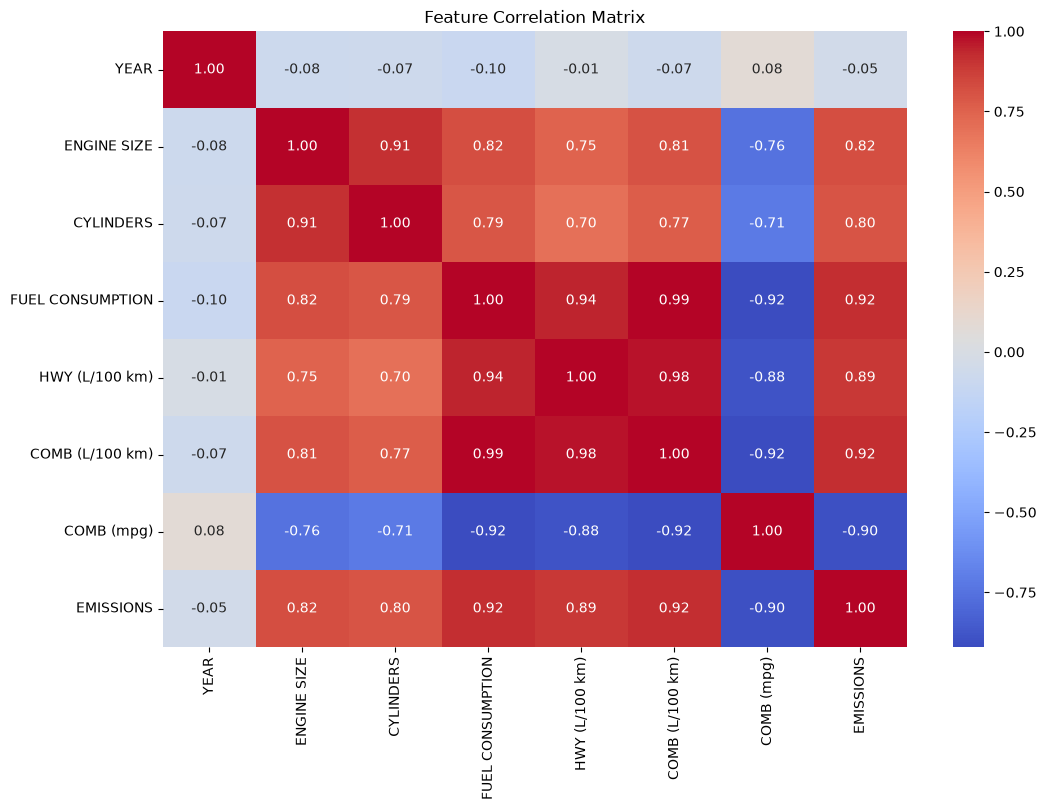

In [20]:
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

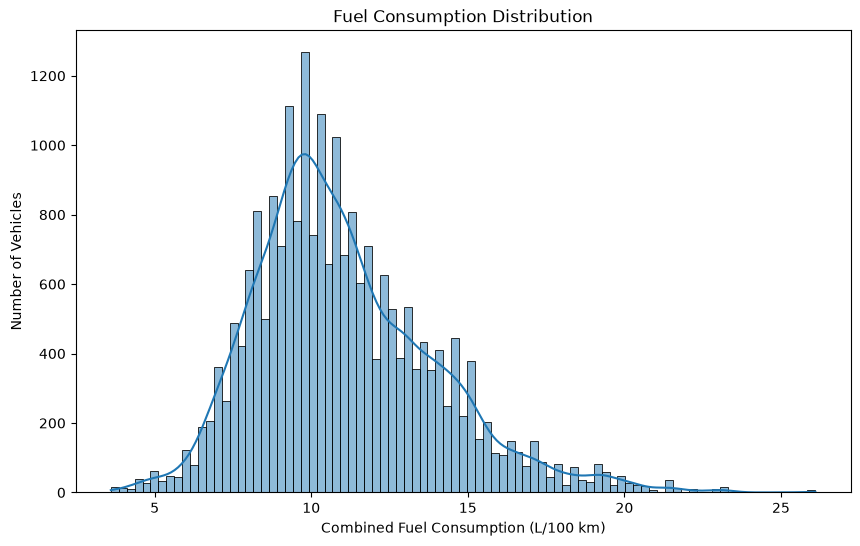

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(df["COMB (L/100 km)"], kde=True)

plt.title("Fuel Consumption Distribution")
plt.xlabel("Combined Fuel Consumption (L/100 km)")
plt.ylabel("Number of Vehicles")

plt.show()

In [16]:
for i, col in enumerate(df.columns):
    print(i, repr(col))

0 'YEAR'
1 'MAKE'
2 'MODEL'
3 'VEHICLE CLASS'
4 'ENGINE SIZE'
5 'CYLINDERS'
6 'TRANSMISSION'
7 'FUEL'
8 'FUEL CONSUMPTION'
9 'HWY (L/100 km)'
10 'COMB (L/100 km)'
11 'COMB (mpg)'
12 'EMISSIONS'


In [14]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['YEAR', 'MAKE', 'MODEL', 'VEHICLE CLASS', 'ENGINE SIZE', 'CYLINDERS', 'TRANSMISSION', 'FUEL', 'FUEL CONSUMPTION', 'HWY (L/100 km)', 'COMB (L/100 km)', 'COMB (mpg)', 'EMISSIONS']


In [10]:
print(df.columns.tolist())


['YEAR', 'MAKE', 'MODEL', 'VEHICLE CLASS', 'ENGINE SIZE', 'CYLINDERS', 'TRANSMISSION', 'FUEL', 'FUEL CONSUMPTION', 'HWY (L/100 km)', 'COMB (L/100 km)', 'COMB (mpg)', 'EMISSIONS']


In [7]:
print(df.columns.tolist())

['YEAR', 'MAKE', 'MODEL', 'VEHICLE CLASS', 'ENGINE SIZE', 'CYLINDERS', 'TRANSMISSION', 'FUEL', 'FUEL CONSUMPTION', 'HWY (L/100 km)', 'COMB (L/100 km)', 'COMB (mpg)', 'EMISSIONS']


In [6]:
missing = df.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [5]:
missing = df.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,22555.0,NaN,NaN,NaN,2011.554955,6.297939,2000.0,2006.0,2012.0,2017.0,2022.0
MAKE,22555,87,CHEVROLET,1725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MODEL,22555,4242,JETTA,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VEHICLE CLASS,22555,32,SUV,2639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENGINE SIZE,22555.0,NaN,NaN,NaN,3.356617,1.335448,0.8,2.3,3.0,4.2,8.4
CYLINDERS,22555.0,NaN,NaN,NaN,5.854046,1.819582,2.0,4.0,6.0,8.0,16.0
TRANSMISSION,22555,30,A4,3518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FUEL,22555,5,X,11822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FUEL CONSUMPTION,22555.0,NaN,NaN,NaN,12.763294,3.500922,3.5,10.4,12.3,14.7,30.6
HWY (L/100 km),22555.0,NaN,NaN,NaN,8.918958,2.274675,3.2,7.3,8.4,10.2,20.9


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22555 entries, 0 to 22554
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              22555 non-null  int64  
 1   MAKE              22555 non-null  str    
 2   MODEL             22555 non-null  str    
 3   VEHICLE CLASS     22555 non-null  str    
 4   ENGINE SIZE       22555 non-null  float64
 5   CYLINDERS         22555 non-null  int64  
 6   TRANSMISSION      22555 non-null  str    
 7   FUEL              22555 non-null  str    
 8   FUEL CONSUMPTION  22555 non-null  float64
 9   HWY (L/100 km)    22555 non-null  float64
 10  COMB (L/100 km)   22555 non-null  float64
 11  COMB (mpg)        22555 non-null  int64  
 12  EMISSIONS         22555 non-null  int64  
dtypes: float64(4), int64(4), str(5)
memory usage: 2.2 MB


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df = pd.read_csv("../data/processed/fuel_cleaned.csv")

print("Shape:", df.shape)
display(df.head())

Matplotlib is building the font cache; this may take a moment.


Shape: (22555, 13)


,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,9.2,6.7,8.1,35,186
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,8.5,6.5,7.6,37,175
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,12.2,7.4,10.0,28,230
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,13.4,9.2,11.5,25,264
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,10.0,7.0,8.6,33,198
